# Pre-entrega 2 — Análisis exploratorio de datos

**Proyecto:** Análisis y predicción del rendimiento productivo en pozos de petróleo y gas de Argentina  
**Programa:** EnergIA Digital — Data Science (Fundación YPF)  
**Integrantes:** Mariapia Ortiz y Antonella Fontanetto  
**Comisión:** 2

## Objetivo

Entender cómo se distribuye la producción mensual de petróleo de los pozos argentinos y qué características
del pozo (cuenca, formación, tipo de recurso, sistema de extracción, profundidad) se asocian a ella.
El análisis deja preparado el terreno para dos modelos posteriores:

- **Supervisado (pre-entrega 3):** predecir la producción mensual de petróleo de un pozo (`prod_pet`).
- **No supervisado (pre-entrega 4):** agrupar pozos según su perfil productivo.

## Dataset

*Producción de petróleo y gas por pozo (Capítulo IV)*, Secretaría de Energía de la Nación,
[datos.energia.gob.ar](http://datos.energia.gob.ar/dataset/produccion-de-petroleo-y-gas-por-pozo).
Se usa el archivo del año 2025, descargado el 02/10/2026. Unidades según el portal:
petróleo en m³, gas en miles de m³ y agua en m³.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, RobustScaler, StandardScaler

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")

## 1. Descripción general

¿Cuántas filas y columnas hay? ¿Qué representa cada fila? ¿De qué tipo es cada variable?

In [2]:
df = pd.read_csv("../data/produccion_pozos_2025.csv.gz", low_memory=False)
print(f"{df.shape[0]:,} filas y {df.shape[1]} columnas")
df.head()

991,936 filas y 39 columnas


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,tipoextraccion,tipoestado,tipopozo,observaciones,fechaingreso,rectificado,habilitado,idusuario,empresa,sigla,formprod,profundidad,formacion,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data,id
0,Z001,2025,1,145622,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Sin Sistema de Extracción,Abandonado,Petrolífero,Cargado automáticamente como [Sin movimientos],2025-02-15 12:35:43.692591,f,t,379,PETROLERA DEL COMAHUE S.A.,JG.DJ.x-2,PROS,"2,402.00",punta rosada,AGR,GENERAL ROCA,AGR,GENERAL ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,145622202501
1,Z001,2025,1,145623,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Plunger Lift,Abandonado,Petrolífero,Cargado automáticamente como [Sin movimientos],2025-02-15 12:35:43.692591,f,t,379,PETROLERA DEL COMAHUE S.A.,YPF.G.x-1,FIMP,"2,500.00",formación improductiva,AGR,GENERAL ROCA,AGR,GENERAL ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,145623202501
2,Z001,2025,1,145625,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Sin Sistema de Extracción,Abandonado,Petrolífero,Cargado automáticamente como [Sin movimientos],2025-02-15 12:35:43.692591,f,t,379,PETROLERA DEL COMAHUE S.A.,YPF.GR.x-5,FIMP,"2,707.00",formación improductiva,AGR,GENERAL ROCA,AGR,GENERAL ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,145625202501
3,Z001,2025,1,32173,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Otros Tipos de Extracción,En Estudio,Gasífero,Cargado automáticamente como [Sin movimientos],2025-02-15 12:35:43.692591,f,t,379,PETROLERA DEL COMAHUE S.A.,PDC.M.x-101,CENT,"1,575.00",centenario,ABO,"BLANCO DE LOS OLIVOS - BLOQUE ""A""",ABO,"BLANCO DE LOS OLIVOS-BLOQUE ""A""",NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31,32173202501
4,Z001,2025,1,145615,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Sin Sistema de Extracción,En Reserva para Recup. Sec./Asist.,Inyección de Agua,Cargado automáticamente como [Sin movimientos],2025-02-15 12:35:43.692591,f,t,379,PETROLERA DEL COMAHUE S.A.,JG.FDRW.x-1,PROS,"2,034.00",punta rosada,Z047,FLOR DE ROCA,FDRO,FLOR DE ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,SERVICIO,SUMIDERO,NaN,2025-01-31,145615202501


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 991936 entries, 0 to 991935
Data columns (total 39 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               991936 non-null  str    
 1   anio                    991936 non-null  int64  
 2   mes                     991936 non-null  int64  
 3   idpozo                  991936 non-null  int64  
 4   prod_pet                991936 non-null  float64
 5   prod_gas                991936 non-null  float64
 6   prod_agua               991936 non-null  float64
 7   iny_agua                991936 non-null  float64
 8   iny_gas                 991936 non-null  float64
 9   iny_co2                 991936 non-null  float64
 10  iny_otro                991936 non-null  float64
 11  tef                     991936 non-null  float64
 12  vida_util               72246 non-null   float64
 13  tipoextraccion          991903 non-null  str    
 14  tipoestado              991903 

Cada fila es la declaración jurada de **un pozo en un mes**. Lo verificamos: la combinación
pozo + año + mes no debe repetirse.

In [4]:
print("Período:", df["anio"].unique(), "meses", df["mes"].min(), "a", df["mes"].max())
print(f"Pozos distintos: {df['idpozo'].nunique():,}")
print("Filas pozo-mes duplicadas:", df.duplicated(["idpozo", "anio", "mes"]).sum())

Período: [2025] meses 1 a 12
Pozos distintos: 83,172
Filas pozo-mes duplicadas: 0


Cardinalidad de las variables categóricas:

In [5]:
df.select_dtypes(exclude="number").nunique().sort_values()

habilitado                    1
rectificado                   2
sub_tipo_recurso              2
proyecto                      2
tipo_de_recurso               4
clasificacion                 4
cuenca                        8
tipopozo                      9
provincia                    11
tipoextraccion               11
fecha_data                   12
subclasificacion             15
tipoestado                   16
idempresa                    69
empresa                      69
formacion                    77
formprod                     79
observaciones               219
areapermisoconcesion        361
idareapermisoconcesion      364
areayacimiento             1076
idareayacimiento           1188
fechaingreso               3169
sigla                     76004
dtype: int64

## 2. Columnas que no aportan al objetivo

Antes de limpiar, descartamos columnas que no describen al pozo ni a su producción:

In [6]:
print("vida_util — % nulos:", round(df["vida_util"].isna().mean() * 100, 1),
      "| valores distintos:", df["vida_util"].dropna().unique())
print("habilitado — valores:", df["habilitado"].unique())
print("observaciones — % nulos:", round(df["observaciones"].isna().mean() * 100, 1))
df["observaciones"].value_counts().head(5)

vida_util — % nulos: 92.7 | valores distintos: [0.]
habilitado — valores: <StringArray>
['t']
Length: 1, dtype: str
observaciones — % nulos: 86.9


observaciones
Cargado automáticamente como [Sin movimientos]                                      72079
ACO                                                                                 21413
No son punzados nuevos, producci ?Â³n previamente declarada en otra formaci ?Â³n     9120
sin observaciones                                                                    8760
Pozo que no forma parte del Inventario de la UTE Aguaragüe                           4317
Name: count, dtype: int64

| Columnas | Motivo |
|---|---|
| `vida_util` | 93 % nula y el resto vale 0 |
| `habilitado` | constante |
| `observaciones` | texto libre, 87 % nula y con la codificación dañada |
| `id`, `idempresa`, `idareapermisoconcesion`, `idareayacimiento`, `sigla` | códigos que repiten otra columna o identifican al pozo |
| `fechaingreso`, `idusuario`, `rectificado`, `fecha_data` | datos administrativos de la carga |
| `iny_agua`, `iny_gas`, `iny_co2`, `iny_otro` | inyección: el proyecto analiza pozos productores |

También quitamos espacios sobrantes en los textos (por ejemplo `"GENERAL ROCA "`).

In [7]:
columnas_descartadas = [
    "vida_util", "habilitado", "observaciones", "id", "idempresa",
    "idareapermisoconcesion", "idareayacimiento", "sigla", "fechaingreso",
    "idusuario", "rectificado", "fecha_data",
    "iny_agua", "iny_gas", "iny_co2", "iny_otro",
]
df = df.drop(columns=columnas_descartadas)

for col in df.select_dtypes(exclude="number").columns:
    df[col] = df[col].str.strip()

df.shape

(991936, 23)

## 3. Valores faltantes

In [8]:
faltantes = df.isna().sum()
pd.DataFrame({
    "faltantes": faltantes[faltantes > 0],
    "porcentaje": (faltantes[faltantes > 0] / len(df) * 100).round(2),
}).sort_values("faltantes", ascending=False)

,faltantes,porcentaje
sub_tipo_recurso,937748,94.54
subclasificacion,200471,20.21
clasificacion,200471,20.21
formacion,33495,3.38
formprod,32160,3.24
cuenca,36,0.00
tipoextraccion,33,0.00
tipoestado,33,0.00
tipopozo,33,0.00


No basta con contar: importa el **patrón**. Revisamos cada caso.

**`sub_tipo_recurso`** (shale / tight) falta casi siempre. ¿Falta al azar?

In [9]:
pd.crosstab(df["tipo_de_recurso"], df["sub_tipo_recurso"].isna().map({True: "falta", False: "presente"}))

sub_tipo_recurso,falta,presente
tipo_de_recurso,,
CONVENCIONAL,932890,12
NO CONVENCIONAL,48,54176
NO DISCRIMINADO,55,0
SIN RESERVORIO,4755,0


No es un faltante al azar: el subtipo sólo existe para el recurso **no convencional**. En los convencionales
el dato *no aplica*. Lo completamos con la categoría `NO APLICA` en lugar de eliminar filas.

**`clasificacion` y `subclasificacion`** faltan en el 20 % de las filas. ¿Depende de la provincia?

In [10]:
(df.groupby("provincia")["clasificacion"]
   .apply(lambda s: s.isna().mean() * 100)
   .sort_values(ascending=False)
   .round(1))

provincia
Jujuy              69.60
Tierra del Fuego   50.20
Santa Cruz         33.00
Formosa            32.80
Estado Nacional    26.60
Chubut             26.20
Salta              23.60
Neuquén             8.10
Mendoza             7.50
Rio Negro           5.80
La Pampa            0.30
Name: clasificacion, dtype: float64

El faltante varía mucho entre provincias (de 0 % en La Pampa a 70 % en Jujuy): depende de quién carga
el dato, es **MAR**. Eliminar esas filas sesgaría la muestra contra Santa Cruz y Chubut, así que lo
marcamos como categoría `SIN DATO`.

**`tipopozo`, `tipoestado`, `tipoextraccion` y `cuenca`** faltan en 69 filas. ¿Qué producen?

In [11]:
sin_tipo = df["tipopozo"].isna() | df["cuenca"].isna()
print("Filas:", sin_tipo.sum(), "| petróleo total declarado:", df.loc[sin_tipo, "prod_pet"].sum())

Filas: 69 | petróleo total declarado: 0.0


In [12]:
df = df[~sin_tipo].copy()
df["sub_tipo_recurso"] = df["sub_tipo_recurso"].fillna("NO APLICA")
df[["clasificacion", "subclasificacion"]] = df[["clasificacion", "subclasificacion"]].fillna("SIN DATO")

Son pocas y no declaran producción: se eliminan sin pérdida.

### Faltantes ocultos y valores imposibles

Hay faltantes que no aparecen como nulos. Revisamos los rangos físicos de cada variable:

- La producción no puede ser negativa.
- `tef` es el tiempo efectivo de producción en días (el 99,9 % de los valores es ≤ 31): no puede ser negativo ni superar 31.
- Una profundidad de 0 m no es un pozo real: es un dato no cargado. Tampoco lo es 378.939 m.

In [13]:
pd.Series({
    "producción negativa (pet, gas o agua)": (df[["prod_pet", "prod_gas", "prod_agua"]] < 0).any(axis=1).sum(),
    "tef < 0 o tef > 31": ((df["tef"] < 0) | (df["tef"] > 31)).sum(),
    "profundidad = 0": (df["profundidad"] == 0).sum(),
    "profundidad > 8.000 m": (df["profundidad"] > 8000).sum(),
}, name="filas")

producción negativa (pet, gas o agua)         7
tef < 0 o tef > 31                          103
profundidad = 0                          121686
profundidad > 8.000 m                       141
Name: filas, dtype: int64

Decisiones:

- **Producción negativa y `tef` fuera de rango:** son unas 110 filas con errores de carga; se eliminan.
- **Profundidad 0 o mayor a 8.000 m:** se convierte en faltante (`NaN`). Tomamos 8.000 m como techo por criterio
  propio: los valores que lo superan son de un orden de magnitud imposible. Los imputaremos con la mediana de su
  formación geológica, **calculada sólo con los datos de entrenamiento** (sección 10), para no filtrar información del test.

In [14]:
erroneas = (df[["prod_pet", "prod_gas", "prod_agua"]] < 0).any(axis=1) | (df["tef"] < 0) | (df["tef"] > 31)
df = df[~erroneas].copy()
df.loc[(df["profundidad"] == 0) | (df["profundidad"] > 8000), "profundidad"] = np.nan
print(f"{len(df):,} filas | profundidad faltante: {df['profundidad'].isna().mean() * 100:.1f} %")

991,761 filas | profundidad faltante: 12.3 %


## 4. Universo del análisis: pozos petroleros en producción

La variable a predecir es la producción de petróleo. ¿Qué pozos la tienen?

In [15]:
(df.groupby("tipoestado")["prod_pet"]
   .agg(filas="size", porcentaje_con_petroleo=lambda s: (s > 0).mean() * 100)
   .sort_values("filas", ascending=False))

,filas,porcentaje_con_petroleo
tipoestado,,
Extracción Efectiva,314154,88.51
Abandonado,228801,0.00
En Reserva para Recup. Sec./Asist.,104257,0.02
En Estudio,98521,0.35
En Inyección Efectiva,72048,0.04
Parado Transitoriamente,63243,6.44
A Abandonar,31929,0.01
En Espera de Reparación,22629,0.24
Abandono Temporario,16611,0.00


Los pozos abandonados, parados o de inyección declaran 0 m³ casi siempre: no aportan a la pregunta y sólo
inflarían la cantidad de ceros. Nos quedamos con los pozos **petrolíferos en extracción efectiva**.

In [16]:
pet = df[(df["tipopozo"] == "Petrolífero") & (df["tipoestado"] == "Extracción Efectiva")].copy()
print(f"{len(pet):,} filas pozo-mes | {pet['idpozo'].nunique():,} pozos")
print("Meses declarados por pozo:")
pet.groupby("idpozo").size().value_counts().sort_index(ascending=False).head(6)

263,937 filas pozo-mes | 24,388 pozos
Meses declarados por pozo:


12    17776
11     1970
10      865
9       622
8       525
7       403
Name: count, dtype: int64

In [17]:
faltantes_pet = pet.isna().sum()
faltantes_pet[faltantes_pet > 0]

formprod         243
profundidad    18026
formacion        255
dtype: int64

En este subconjunto sólo quedan faltantes en la profundidad (se imputa en la sección 10) y en la formación
productiva. Las filas sin formación se marcan como `SIN DATO`.

In [18]:
pet[["formprod", "formacion"]] = pet[["formprod", "formacion"]].fillna("SIN DATO")

## 5. Análisis univariado

### Variables numéricas

In [19]:
numericas = ["prod_pet", "prod_gas", "prod_agua", "tef", "profundidad"]
pet[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
prod_pet,"263,937.00",162.16,563.54,0.00,17.33,41.72,93.07,"26,593.26"
prod_gas,"263,937.00",28.71,150.92,0.00,0.00,1.40,8.01,"7,190.69"
prod_agua,"263,937.00","1,211.01","1,940.42",0.00,46.23,387.28,"1,560.61","37,771.49"
tef,"263,937.00",27.15,7.92,0.00,28.00,30.00,30.96,31.00
profundidad,"245,911.00","2,117.93","1,205.23",1.00,"1,312.00","1,936.00","2,481.00","7,922.00"


In [20]:
pd.DataFrame({
    "asimetría": pet[numericas].skew(),
    "curtosis": pet[numericas].kurt(),
}).round(2)

,asimetría,curtosis
prod_pet,9.07,126.90
prod_gas,14.69,344.20
prod_agua,3.03,13.66
tef,-2.71,6.12
profundidad,1.91,4.27


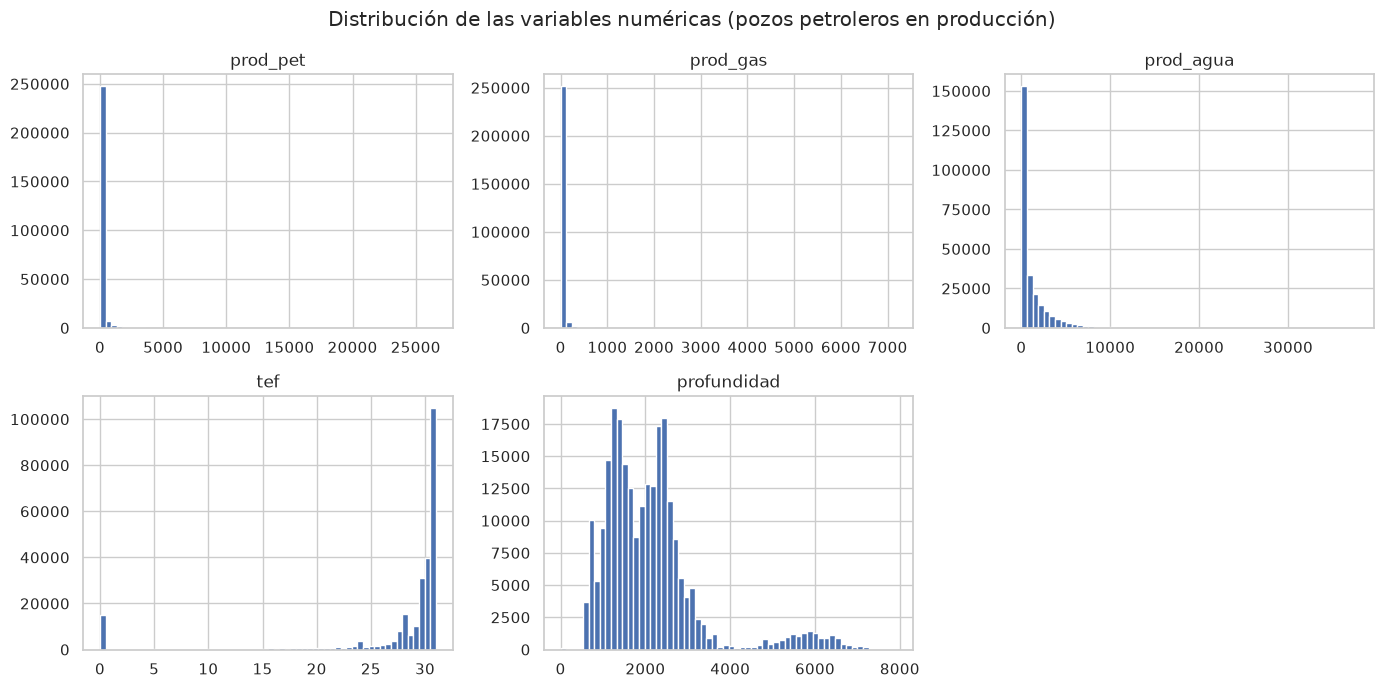

In [21]:
pet[numericas].hist(bins=60, figsize=(14, 7), layout=(2, 3))
plt.suptitle("Distribución de las variables numéricas (pozos petroleros en producción)")
plt.tight_layout()
plt.show()

Las tres producciones tienen **asimetría positiva extrema** (muy por encima del umbral |skew| > 1): la mayoría
de los pozos produce poco y unos pocos producen muchísimo. La media queda muy por encima de la mediana, así que
para resumir conviene la mediana. `tef` se concentra en 28-31 días: casi todos los pozos productivos trabajan el mes completo.

El Q-Q plot compara los cuantiles de `prod_pet` con los de una normal, antes y después de aplicar logaritmo:

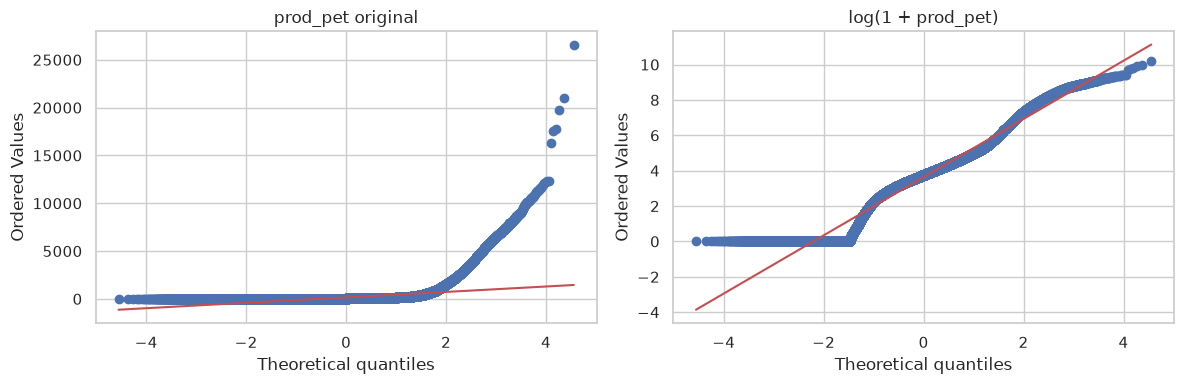

D'Agostino-Pearson sobre log1p: p = 0


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(pet["prod_pet"], dist="norm", plot=axes[0])
axes[0].set_title("prod_pet original")
stats.probplot(np.log1p(pet["prod_pet"]), dist="norm", plot=axes[1])
axes[1].set_title("log(1 + prod_pet)")
plt.tight_layout()
plt.show()

estadistico, p_valor = stats.normaltest(np.log1p(pet["prod_pet"]))
print(f"D'Agostino-Pearson sobre log1p: p = {p_valor:.3g}")

El logaritmo acerca mucho la variable a una recta, aunque el test de D'Agostino-Pearson igual rechaza la
normalidad: con más de 260.000 filas cualquier desvío mínimo resulta significativo. Como vimos en clase,
**el test no manda solo**: el Q-Q plot y la asimetría muestran una mejora clara.

### Variables categóricas

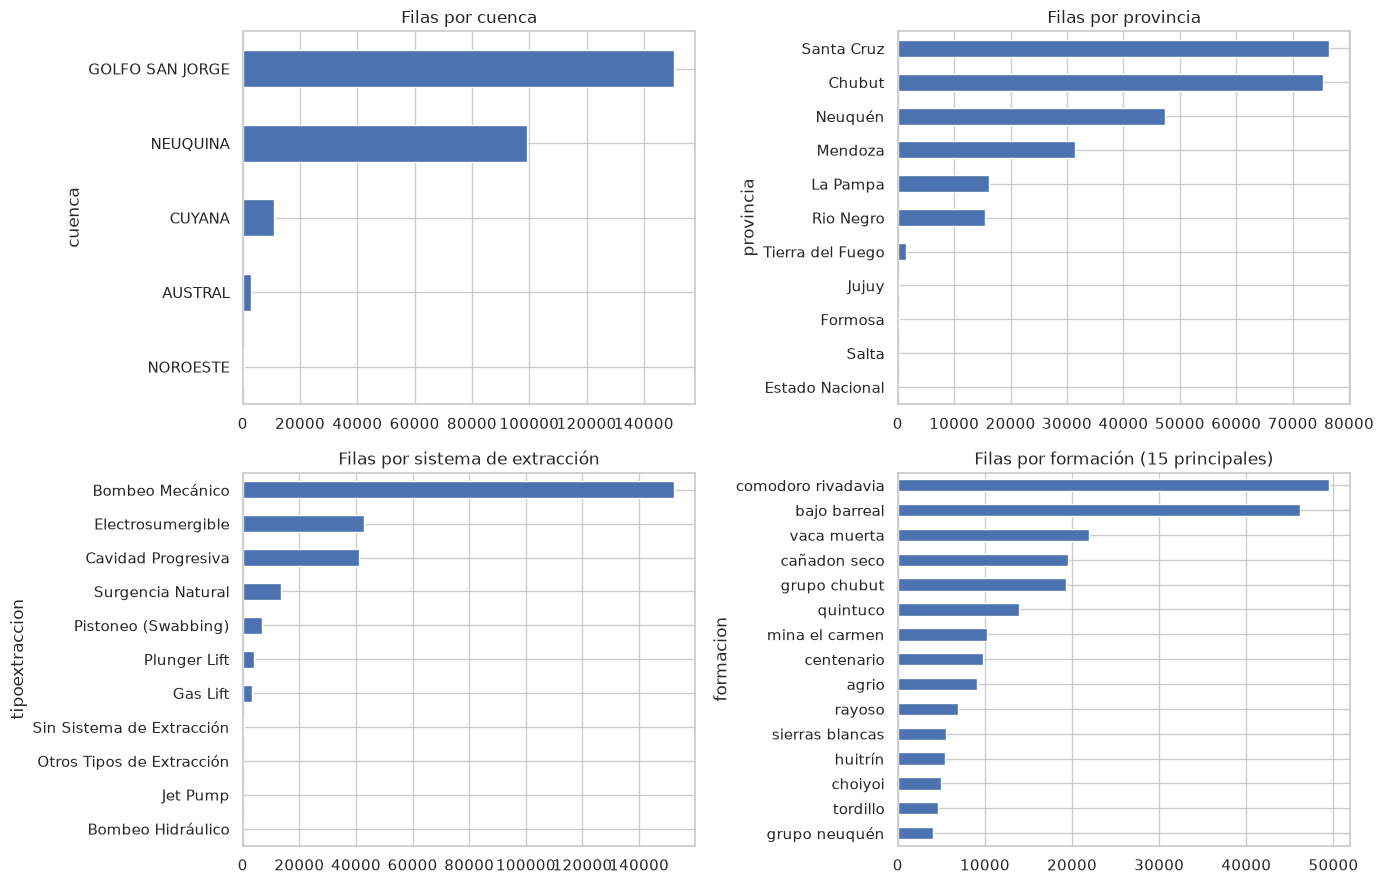

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
pet["cuenca"].value_counts().plot.barh(ax=axes[0, 0], title="Filas por cuenca")
pet["provincia"].value_counts().plot.barh(ax=axes[0, 1], title="Filas por provincia")
pet["tipoextraccion"].value_counts().plot.barh(ax=axes[1, 0], title="Filas por sistema de extracción")
pet["formacion"].value_counts().head(15).plot.barh(ax=axes[1, 1], title="Filas por formación (15 principales)")
for ax in axes.flat:
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
pet["tipo_de_recurso"].value_counts(normalize=True).mul(100).round(1)

tipo_de_recurso
CONVENCIONAL      91.60
NO CONVENCIONAL    8.40
NO DISCRIMINADO    0.00
Name: proportion, dtype: float64

Las categorías están **desbalanceadas**: Golfo San Jorge concentra la mayoría de las filas, el bombeo mecánico
domina los sistemas de extracción y sólo una fracción pequeña de las filas es no convencional. Hay además
categorías muy poco frecuentes (por ejemplo, bombeo hidráulico con una sola fila), que habrá que agrupar
antes de codificar.

## 6. Análisis bivariado: ¿qué se asocia a la producción?

### Tipo de recurso

In [25]:
resumen_recurso = pet.groupby("tipo_de_recurso").agg(
    filas=("prod_pet", "size"),
    mediana_m3_mes=("prod_pet", "median"),
    petroleo_total_m3=("prod_pet", "sum"),
)
resumen_recurso["% de filas"] = resumen_recurso["filas"] / resumen_recurso["filas"].sum() * 100
resumen_recurso["% del petróleo"] = resumen_recurso["petroleo_total_m3"] / resumen_recurso["petroleo_total_m3"].sum() * 100
resumen_recurso

,filas,mediana_m3_mes,petroleo_total_m3,% de filas,% del petróleo
tipo_de_recurso,,,,,
CONVENCIONAL,241878,38.56,"16,147,376.27",91.64,37.73
NO CONVENCIONAL,22052,664.93,"26,650,775.94",8.36,62.27
NO DISCRIMINADO,7,333.99,"2,273.10",0.00,0.01


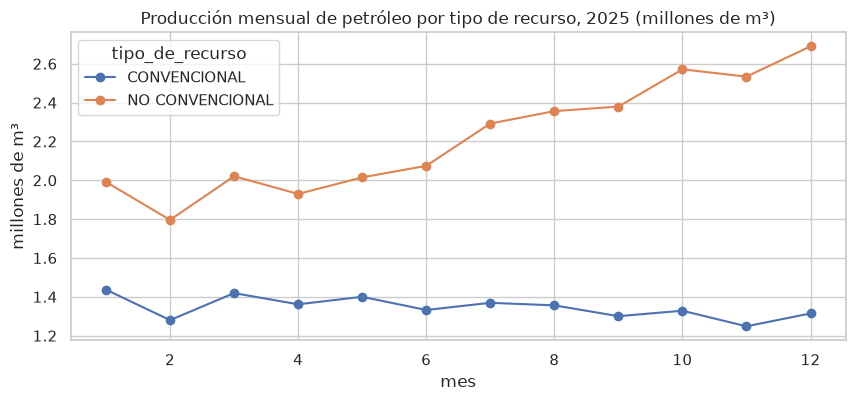

In [26]:
(pet.groupby(["mes", "tipo_de_recurso"])["prod_pet"].sum()
    .unstack()
    .drop(columns="NO DISCRIMINADO", errors="ignore")
    .div(1e6)
    .plot(marker="o", figsize=(10, 4),
          title="Producción mensual de petróleo por tipo de recurso, 2025 (millones de m³)"))
plt.ylabel("millones de m³")
plt.show()

### Sistema de extracción y cuenca

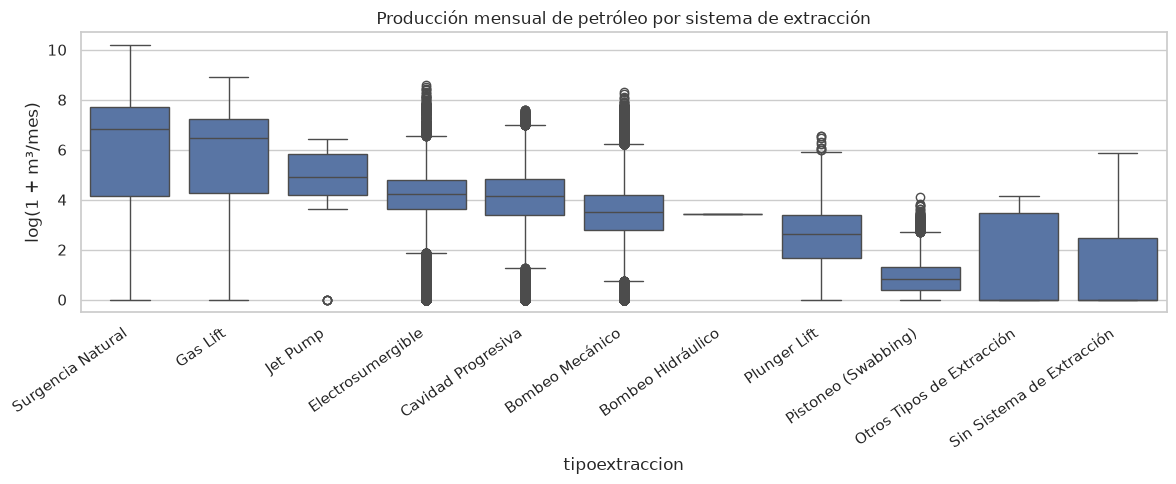

In [27]:
orden = pet.groupby("tipoextraccion")["prod_pet"].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=pet, x="tipoextraccion", y=np.log1p(pet["prod_pet"]), order=orden)
plt.xticks(rotation=35, ha="right")
plt.ylabel("log(1 + m³/mes)")
plt.title("Producción mensual de petróleo por sistema de extracción")
plt.tight_layout()
plt.show()

In [28]:
(pet.groupby("cuenca")
    .agg(pozos=("idpozo", "nunique"),
         mediana_m3_mes=("prod_pet", "median"),
         petroleo_total_m3=("prod_pet", "sum"))
    .sort_values("petroleo_total_m3", ascending=False))

,pozos,mediana_m3_mes,petroleo_total_m3
cuenca,,,
NEUQUINA,9353,42.08,"31,334,022.59"
GOLFO SAN JORGE,13732,40.57,"10,281,568.51"
CUYANA,969,59.66,"841,048.29"
AUSTRAL,296,35.43,"288,067.14"
NOROESTE,38,116.56,"55,718.79"


### Formación geológica

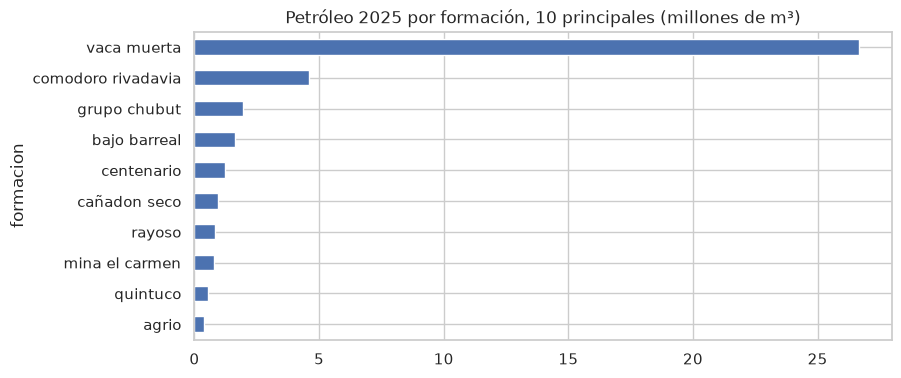

In [29]:
top_formaciones = (pet.groupby("formacion")["prod_pet"].sum()
                      .sort_values(ascending=False).head(10).div(1e6))
top_formaciones.plot.barh(figsize=(9, 4), title="Petróleo 2025 por formación, 10 principales (millones de m³)")
plt.gca().invert_yaxis()
plt.show()

### Relaciones entre variables numéricas

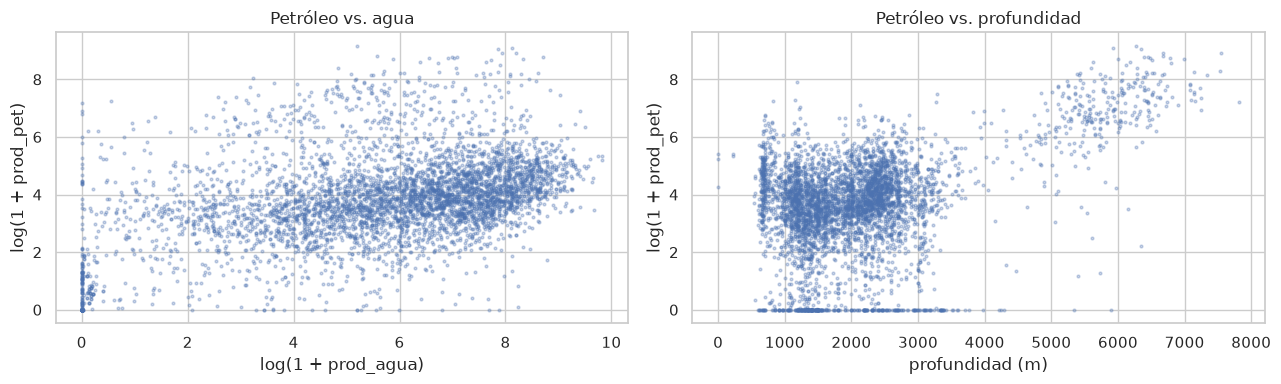

In [30]:
muestra = pet.sample(5000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["prod_agua", "profundidad"]):
    ax.scatter(np.log1p(muestra[col]) if col == "prod_agua" else muestra[col],
               np.log1p(muestra["prod_pet"]), s=4, alpha=0.3)
    ax.set_xlabel("log(1 + prod_agua)" if col == "prod_agua" else "profundidad (m)")
    ax.set_ylabel("log(1 + prod_pet)")
axes[0].set_title("Petróleo vs. agua")
axes[1].set_title("Petróleo vs. profundidad")
plt.tight_layout()
plt.show()

## 7. Outliers: detectar no es eliminar

Comparamos los dos criterios vistos en clase sobre `prod_pet`: el z-score (pensado para distribuciones
simétricas) y el rango intercuartílico (más adecuado para distribuciones sesgadas).

In [31]:
def outliers_zscore(serie, umbral=3):
    z = (serie - serie.mean()) / serie.std()
    return z.abs() > umbral


def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    ric = q3 - q1
    return (serie < q1 - 1.5 * ric) | (serie > q3 + 1.5 * ric)


marcas = pd.DataFrame({
    "z-score": outliers_zscore(pet["prod_pet"]),
    "RIC": outliers_iqr(pet["prod_pet"]),
    "RIC sobre log1p": outliers_iqr(np.log1p(pet["prod_pet"])),
})
marcas.mean().mul(100).round(1).rename("% de filas marcadas")

z-score            1.80
RIC               11.00
RIC sobre log1p   10.90
Name: % de filas marcadas, dtype: float64

In [32]:
(pd.crosstab(pet["tipo_de_recurso"], marcas["RIC"], normalize="index")
   .mul(100).round(1)
   .rename(columns={False: "% normal", True: "% outlier (RIC)"}))

RIC,% normal,% outlier (RIC)
tipo_de_recurso,,
CONVENCIONAL,94.50,5.50
NO CONVENCIONAL,28.90,71.10
NO DISCRIMINADO,0.00,100.00


El RIC marca como atípicos a la mayoría de los pozos **no convencionales**. No son errores: son los pozos
de Vaca Muerta, que producen un orden de magnitud más que un pozo convencional. Eliminarlos borraría la
parte más importante de la producción del país.

**Decisión:** no se eliminan. Su peso se controla transformando la variable (sección 9) y, si hace falta
escalar, con `RobustScaler`, que usa mediana y RIC. Los errores de carga reales ya se trataron en la sección 3.

## 8. Feature engineering

### Variables derivadas

- **`caudal_diario`** = `prod_pet / tef`: producción por día efectivo. Hace comparables a un pozo que
  trabajó 31 días con otro que trabajó 10.
- **`corte_agua`** = `prod_agua / (prod_agua + prod_pet)`: fracción de agua en el líquido extraído. Un corte
  alto indica un pozo maduro.
- **`rgp`** (relación gas-petróleo) = `prod_gas × 1000 / prod_pet`: m³ de gas por m³ de petróleo
  (el gas viene en miles de m³).

In [33]:
pet["caudal_diario"] = (pet["prod_pet"] / pet["tef"]).where(pet["tef"] > 0)
liquido = pet["prod_agua"] + pet["prod_pet"]
pet["corte_agua"] = (pet["prod_agua"] / liquido).where(liquido > 0)
pet["rgp"] = (pet["prod_gas"] * 1000 / pet["prod_pet"]).where(pet["prod_pet"] > 0)

pet[["caudal_diario", "corte_agua", "rgp"]].describe().T

,count,mean,std,min,25%,50%,75%,max
caudal_diario,"249,168.00",6.28,163.43,0.00,0.77,1.58,3.39,"80,986.14"
corte_agua,"247,360.00",0.75,0.31,0.00,0.61,0.91,0.97,1.00
rgp,"246,261.00",859.56,"31,767.32",0.00,0.00,36.79,169.47,"7,262,333.21"


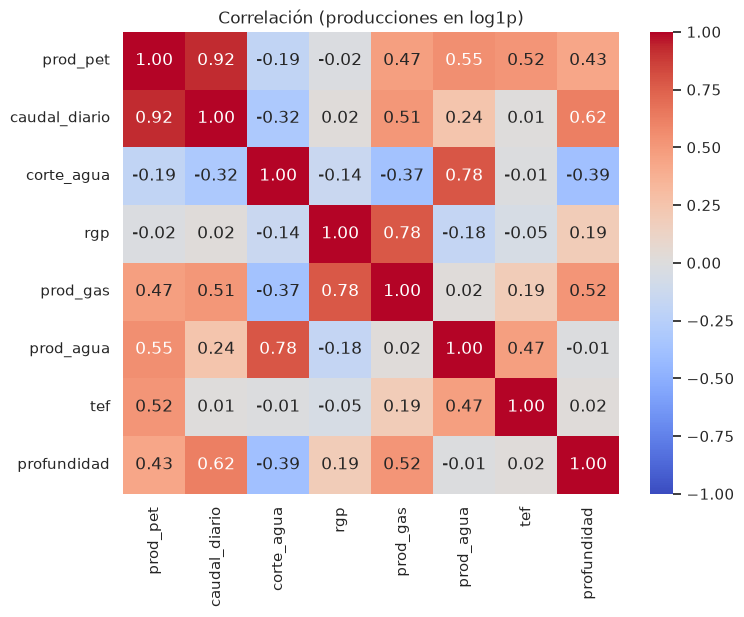

In [34]:
derivadas = ["prod_pet", "caudal_diario", "corte_agua", "rgp", "prod_gas", "prod_agua", "tef", "profundidad"]
asimetricas_corr = ["prod_pet", "caudal_diario", "rgp", "prod_gas", "prod_agua"]
para_correlacion = pet[derivadas].copy()
para_correlacion[asimetricas_corr] = np.log1p(para_correlacion[asimetricas_corr])

plt.figure(figsize=(8, 6))
sns.heatmap(para_correlacion.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación (producciones en log1p)")
plt.show()

Los máximos de `caudal_diario` (unos 81.000 m³/día) y de `rgp` son irreales: aparecen cuando `tef` es de
apenas horas o cuando el pozo declaró una cantidad mínima de petróleo, y la división dispara el resultado.
Antes de modelar con estas variables conviene exigir un mínimo de días efectivos.

Las producciones se pasan a `log1p` antes de correlacionar: con una asimetría tan fuerte, la media y el desvío
dejan de ser buenos resúmenes (clase 8), y la correlación, que se calcula con ellos, quedaría dominada por
unos pocos pozos extremos.

Entre las características del pozo, la que más acompaña a la producción es la **profundidad** (0,43 con
`prod_pet` y 0,62 con el caudal diario): los pozos más profundos son los de Vaca Muerta. Las correlaciones
altas entre producciones del mismo mes (por ejemplo, agua y corte de agua) son esperables, porque una
variable se calcula con la otra.

### Binning

In [35]:
pet["rango_profundidad"] = pd.cut(
    pet["profundidad"],
    bins=[0, 1000, 2000, 3000, np.inf],
    labels=["< 1.000 m", "1.000-2.000 m", "2.000-3.000 m", "> 3.000 m"],
)
pet.groupby("rango_profundidad", observed=True)["prod_pet"].agg(["size", "median"])

,size,median
rango_profundidad,,
< 1.000 m,24002,54.59
1.000-2.000 m,105164,30.13
2.000-3.000 m,87077,48.40
> 3.000 m,29668,250.65


In [36]:
pet["rango_productividad"] = pd.qcut(pet["prod_pet"], q=3, labels=["Baja", "Media", "Alta"])
pet.groupby("rango_productividad", observed=True)["prod_pet"].agg(["size", "min", "max"])

,size,min,max
rango_productividad,,,
Baja,87979,0.00,24.87
Media,87979,24.87,68.74
Alta,87979,68.75,"26,593.26"


`rango_productividad` divide los pozos-mes en tres grupos del mismo tamaño. Es una candidata a variable
objetivo para el modelo de **clasificación** de la pre-entrega 3. Para modelar, los cortes de los tres
rangos deberán calcularse sólo con entrenamiento.

### Encoding

Los algoritmos esperan números. Para las predictoras usamos variables indicadoras (`get_dummies`);
`LabelEncoder` queda reservado para la variable objetivo, porque inventa un orden que las categorías no tienen.

`formprod` tiene más de 60 categorías: antes de codificar agrupamos las poco frecuentes en `OTRAS`.

In [37]:
principales = pet["formprod"].value_counts().head(10).index
pet["formprod_agrupada"] = pet["formprod"].where(pet["formprod"].isin(principales), "OTRAS")

categoricas = ["cuenca", "tipo_de_recurso", "tipoextraccion", "formprod_agrupada"]
codificado = pd.get_dummies(pet[categoricas], dtype=int)
print("Columnas antes:", len(categoricas), "| después:", codificado.shape[1])
codificado.head()

Columnas antes: 4 | después: 30


,cuenca_AUSTRAL,cuenca_CUYANA,cuenca_GOLFO SAN JORGE,cuenca_NEUQUINA,cuenca_NOROESTE,tipo_de_recurso_CONVENCIONAL,tipo_de_recurso_NO CONVENCIONAL,tipo_de_recurso_NO DISCRIMINADO,tipoextraccion_Bombeo Hidráulico,tipoextraccion_Bombeo Mecánico,tipoextraccion_Cavidad Progresiva,tipoextraccion_Electrosumergible,tipoextraccion_Gas Lift,tipoextraccion_Jet Pump,tipoextraccion_Otros Tipos de Extracción,tipoextraccion_Pistoneo (Swabbing),tipoextraccion_Plunger Lift,tipoextraccion_Sin Sistema de Extracción,tipoextraccion_Surgencia Natural,formprod_agrupada_AGRI,formprod_agrupada_BBAR,formprod_agrupada_CENT,formprod_agrupada_CORI,formprod_agrupada_CSEC,formprod_agrupada_GCHU,formprod_agrupada_MELC,formprod_agrupada_OTRAS,formprod_agrupada_QTUC,formprod_agrupada_RAYO,formprod_agrupada_VMUT
6,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
16,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
17,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
27,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
41,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0


Este encoding es exploratorio. En la pre-entrega 3 lo hará `OneHotEncoder` dentro de un pipeline,
ajustado sólo con entrenamiento.

## 9. Transformación de la forma de la distribución

Las producciones tienen |skew| muy por encima de 1: piden transformación. Comparamos `log1p`
(tolera ceros) con Yeo-Johnson (busca el exponente que más acerca la variable a una normal).

In [38]:
asimetricas = ["prod_pet", "caudal_diario", "prod_agua", "prod_gas"]
pt = PowerTransformer(method="yeo-johnson", standardize=False)
yeo = pd.DataFrame(pt.fit_transform(pet[asimetricas].fillna(0)), columns=asimetricas, index=pet.index)

pd.DataFrame({
    "original": pet[asimetricas].skew(),
    "log1p": np.log1p(pet[asimetricas]).skew(),
    "yeo-johnson": yeo.skew(),
}).round(2)

,original,log1p,yeo-johnson
prod_pet,9.07,-0.20,0.01
caudal_diario,488.31,1.77,0.12
prod_agua,3.03,-0.74,-0.13
prod_gas,14.69,1.29,0.34


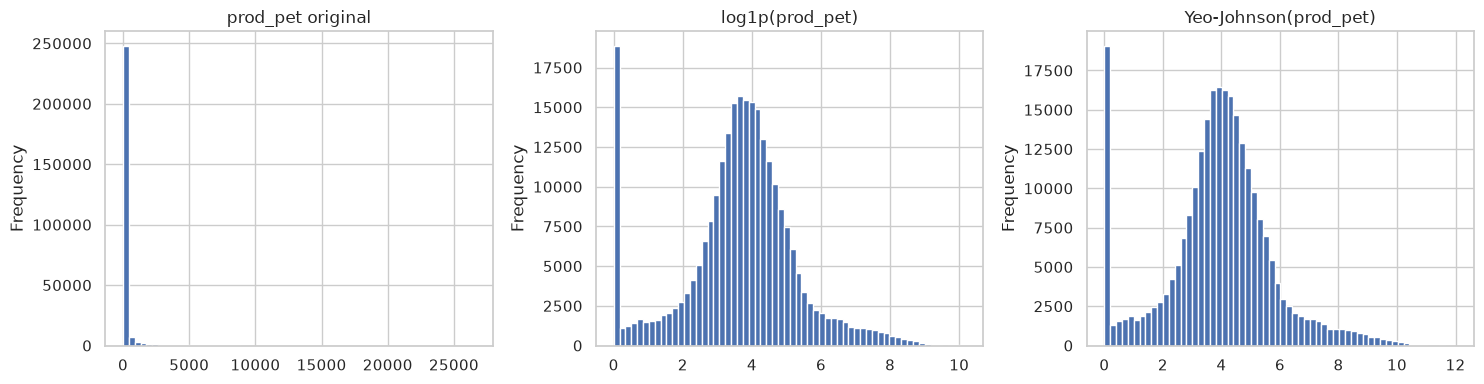

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pet["prod_pet"].plot.hist(bins=60, ax=axes[0], title="prod_pet original")
np.log1p(pet["prod_pet"]).plot.hist(bins=60, ax=axes[1], title="log1p(prod_pet)")
yeo["prod_pet"].plot.hist(bins=60, ax=axes[2], title="Yeo-Johnson(prod_pet)")
plt.tight_layout()
plt.show()

Esta comparación es descriptiva: el `PowerTransformer` se ajustó con todo el dataset sólo para mirar la forma.
Para modelar se ajusta con entrenamiento, como mostramos en la sección siguiente. `log1p` no aprende
parámetros, así que puede aplicarse antes de separar sin filtrar información.

## 10. Separación en entrenamiento y test, imputación y escalado

**El orden importa:** primero se separa, después se ajusta cualquier transformación.

Hay una trampa propia de este dataset: cada pozo aparece hasta 12 veces (una por mes). Si separamos filas
al azar, el mismo pozo queda en entrenamiento y en test, y el modelo "reconoce" pozos que ya vio.
Separamos **por pozo**: es la misma idea de `GroupKFold` de la clase 16 (todas las filas de un mismo grupo
quedan del mismo lado), aplicada a una sola separación con `GroupShuffleSplit`.

In [40]:
separador = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_train, idx_test = next(separador.split(pet, groups=pet["idpozo"]))
train, test = pet.iloc[idx_train].copy(), pet.iloc[idx_test].copy()

print(f"Entrenamiento: {len(train):,} filas, {train['idpozo'].nunique():,} pozos")
print(f"Test: {len(test):,} filas, {test['idpozo'].nunique():,} pozos")
print("Pozos en ambos conjuntos:", len(set(train["idpozo"]) & set(test["idpozo"])))

Entrenamiento: 211,183 filas, 19,510 pozos
Test: 52,754 filas, 4,878 pozos
Pozos en ambos conjuntos: 0


Imputación de la profundidad con la mediana de cada formación, **aprendida sólo de entrenamiento**:

In [41]:
mediana_formacion = train.groupby("formacion")["profundidad"].median()
mediana_global = train["profundidad"].median()

for conjunto in (train, test):
    faltante = conjunto["profundidad"].isna()
    conjunto.loc[faltante, "profundidad"] = (
        conjunto.loc[faltante, "formacion"].map(mediana_formacion).fillna(mediana_global)
    )

print("Faltantes restantes:", train["profundidad"].isna().sum(), "/", test["profundidad"].isna().sum())

Faltantes restantes: 0 / 0


Escalado: `fit_transform` una sola vez sobre entrenamiento; `transform` sobre test. Comparamos los tres
escaladores de la clase 8 sobre `profundidad` y `tef`.

In [42]:
a_escalar = ["profundidad", "tef"]
standard = StandardScaler().fit(train[a_escalar])
robust = RobustScaler().fit(train[a_escalar])
minmax = MinMaxScaler().fit(train[a_escalar])

yeo_train = PowerTransformer(method="yeo-johnson").fit(train[["prod_pet"]])

pd.DataFrame({
    "media test (Standard)": standard.transform(test[a_escalar]).mean(axis=0),
    "desvío test (Standard)": standard.transform(test[a_escalar]).std(axis=0),
    "mediana test (Robust)": np.median(robust.transform(test[a_escalar]), axis=0),
    "mín. test (MinMax)": minmax.transform(test[a_escalar]).min(axis=0),
    "máx. test (MinMax)": minmax.transform(test[a_escalar]).max(axis=0),
}, index=a_escalar).round(3)

,media test (Standard),desvío test (Standard),mediana test (Robust),mín. test (MinMax),máx. test (MinMax)
profundidad,0.03,1.03,0.03,0.07,0.99
tef,0.00,1.00,0.00,0.00,1.00


In [43]:
print("Lambda de Yeo-Johnson aprendido en entrenamiento:", yeo_train.lambdas_.round(3))
print("Asimetría de prod_pet en test, transformada:",
      round(pd.Series(yeo_train.transform(test[["prod_pet"]]).ravel()).skew(), 2))

Lambda de Yeo-Johnson aprendido en entrenamiento: [0.032]
Asimetría de prod_pet en test, transformada: 0.02


El test transformado queda con media cercana a 0 y desvío cercano a 1, pero no exactos: es la señal de que
los parámetros se aprendieron sin mirarlo. Con `MinMaxScaler` puede pasar además que el test quede apenas
fuera de [0, 1], si trae valores más extremos que los de entrenamiento.

Qué escalar depende del modelo: KNN, SVM, regresión lineal y K-Means lo necesitan; los árboles y random forest no.

## 11. Dataset procesado

Guardamos el subconjunto limpio, con las variables derivadas y sin escalar ni codificar: esas
transformaciones se ajustan dentro del pipeline de cada modelo.

In [44]:
columnas_finales = [
    "idpozo", "anio", "mes", "empresa", "provincia", "cuenca", "areayacimiento",
    "formprod", "formacion", "tipo_de_recurso", "sub_tipo_recurso", "tipoextraccion",
    "clasificacion", "subclasificacion", "proyecto", "profundidad", "tef",
    "prod_pet", "prod_gas", "prod_agua", "caudal_diario", "corte_agua", "rgp",
    "rango_profundidad", "rango_productividad",
]
pet[columnas_finales].to_csv("../data/processed/pozos_petroleros_2025.csv.gz", index=False)
print(f"Guardado: {len(pet):,} filas x {len(columnas_finales)} columnas")

Guardado: 263,937 filas x 25 columnas


## 12. Conclusiones

**Qué hay en los datos.** El archivo 2025 tiene 991.936 declaraciones mensuales de 83.172 pozos. Después de
limpiar y quedarnos con los pozos petrolíferos en extracción efectiva, el análisis trabaja con 263.937
filas de 24.388 pozos.

**Calidad del dato.** Los faltantes no son todos iguales: el subtipo de recurso falta porque no aplica al
convencional (estructural), la clasificación falta según la provincia que carga (MAR) y la profundidad
tiene faltantes ocultos como ceros (12 % de las filas). Los errores de carga reales, como producciones
negativas o días efectivos fuera de rango, son unas 110 filas.

**El hallazgo principal: pocos pozos no convencionales sostienen la producción.** Representan el 8,4 % de
las filas pero aportan el 62,3 % del petróleo, con una mediana de 665 m³/mes contra 39 m³/mes de un pozo
convencional. Por eso la cuenca Neuquina, con menos pozos que Golfo San Jorge (9.353 contra 13.732),
produjo el 73 % del petróleo de este subconjunto. La brecha además se agranda: durante 2025 la producción
no convencional pasó de unos 2,0 a 2,7 millones de m³ por mes, mientras la convencional se mantuvo
entre 1,3 y 1,4 millones.

**Distribución y outliers.** La producción de petróleo es muy asimétrica (skew 9,07). Yeo-Johnson la lleva a
0,01 y `log1p` a -0,20. El RIC marca como atípico al 11 % de las filas, pero el 71 % de los pozos no
convencionales cae ahí: son pozos válidos y no se eliminan.

**Madurez.** La mediana del corte de agua es 0,91: en la mayoría de los pozos, por cada m³ de líquido
extraído, más de 9 de cada 10 partes son agua.

### Decisiones para la pre-entrega 3

- **Variable objetivo de regresión:** `prod_pet`, transformada con Yeo-Johnson o `log1p`.
- **Predictoras:** características del pozo (cuenca, formación, tipo de recurso, sistema de extracción,
  profundidad, días efectivos). **No** se usarán `prod_gas`, `prod_agua`, `caudal_diario`, `corte_agua` ni `rgp`
  del mismo mes: se miden al mismo tiempo que el objetivo (o se calculan con él), y usarlas sería data
  leakage. Una alternativa válida es la producción del **mes anterior** del mismo pozo.
- **Clasificación:** `rango_productividad` (baja, media o alta), con los cortes calculados en entrenamiento.
- **Separación:** siempre por pozo (`GroupShuffleSplit`, y `GroupKFold` en la validación cruzada), nunca por fila.